# Bài tập: Dự đoán Doanh số Sản phẩm (Predicting Product Sales)
* **Họ tên:** Đỗ Hữu Khang
* **MSSV:** 2580101060

Sử dụng bộ dữ liệu `E-Commerce Sales` để dự đoán **Total Price** (tổng giá trị đơn hàng) dựa trên các đặc trưng như tuổi, giới tính, khu vực, giá đơn vị, số lượng, phí vận chuyển, v.v.

## 1. Thiết lập môi trường và Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Bỏ qua cảnh báo
import warnings
warnings.filterwarnings('ignore')

## 2. Tải và Khám phá dữ liệu (EDA)

In [2]:
# Load dữ liệu
df = pd.read_csv('realistic_e_commerce_sales_data.csv')

# Xem 5 dòng đầu
display(df.head())

# Xem thông tin dữ liệu
print("\n--- THÔNG TIN DỮ LIỆU ---")
df.info()

# Thống kê cơ bản
display(df.describe())

,Customer ID,Gender,Region,Age,Product Name,Category,Unit Price,Quantity,Total Price,Shipping Fee,Shipping Status,Order Date
0,CUST0268,Male,North,NaN,Monitor,Electronics,300.0,5,1500,13.31,Returned,2023-12-08
1,CUST0046,Male,West,22.0,Headphones,Accessories,100.0,2,200,6.93,In Transit,2023-04-09
2,CUST0169,Female,South,54.0,Monitor,Electronics,300.0,1,300,11.31,Returned,2023-08-28
3,CUST0002,Male,North,23.0,Headphones,Accessories,100.0,5,500,12.22,Delivered,2023-01-18
4,CUST0173,Female,South,NaN,Laptop,Electronics,1500.0,3,4500,5.40,Delivered,2023-01-19



--- THÔNG TIN DỮ LIỆU ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer ID      1000 non-null   str    
 1   Gender           1000 non-null   str    
 2   Region           950 non-null    str    
 3   Age              900 non-null    float64
 4   Product Name     1000 non-null   str    
 5   Category         1000 non-null   str    
 6   Unit Price       1000 non-null   float64
 7   Quantity         1000 non-null   int64  
 8   Total Price      1000 non-null   int64  
 9   Shipping Fee     1000 non-null   float64
 10  Shipping Status  950 non-null    str    
 11  Order Date       1000 non-null   str    
dtypes: float64(3), int64(2), str(7)
memory usage: 93.9 KB


,Age,Unit Price,Quantity,Total Price,Shipping Fee
count,900.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,46.695556,457.703777,3.008000,1346.600000,12.416390
std,15.011400,537.231434,1.404246,1834.037877,4.412185
min,18.000000,30.000000,1.000000,30.000000,5.000000
25%,35.000000,50.000000,2.000000,200.000000,8.560000
50%,49.000000,200.000000,3.000000,600.000000,12.315000
75%,59.000000,800.000000,4.000000,1500.000000,16.075000
max,69.000000,3109.560612,5.000000,7500.000000,19.980000


### 2.1. Phân phối các biến số (Numerical Features Distribution)

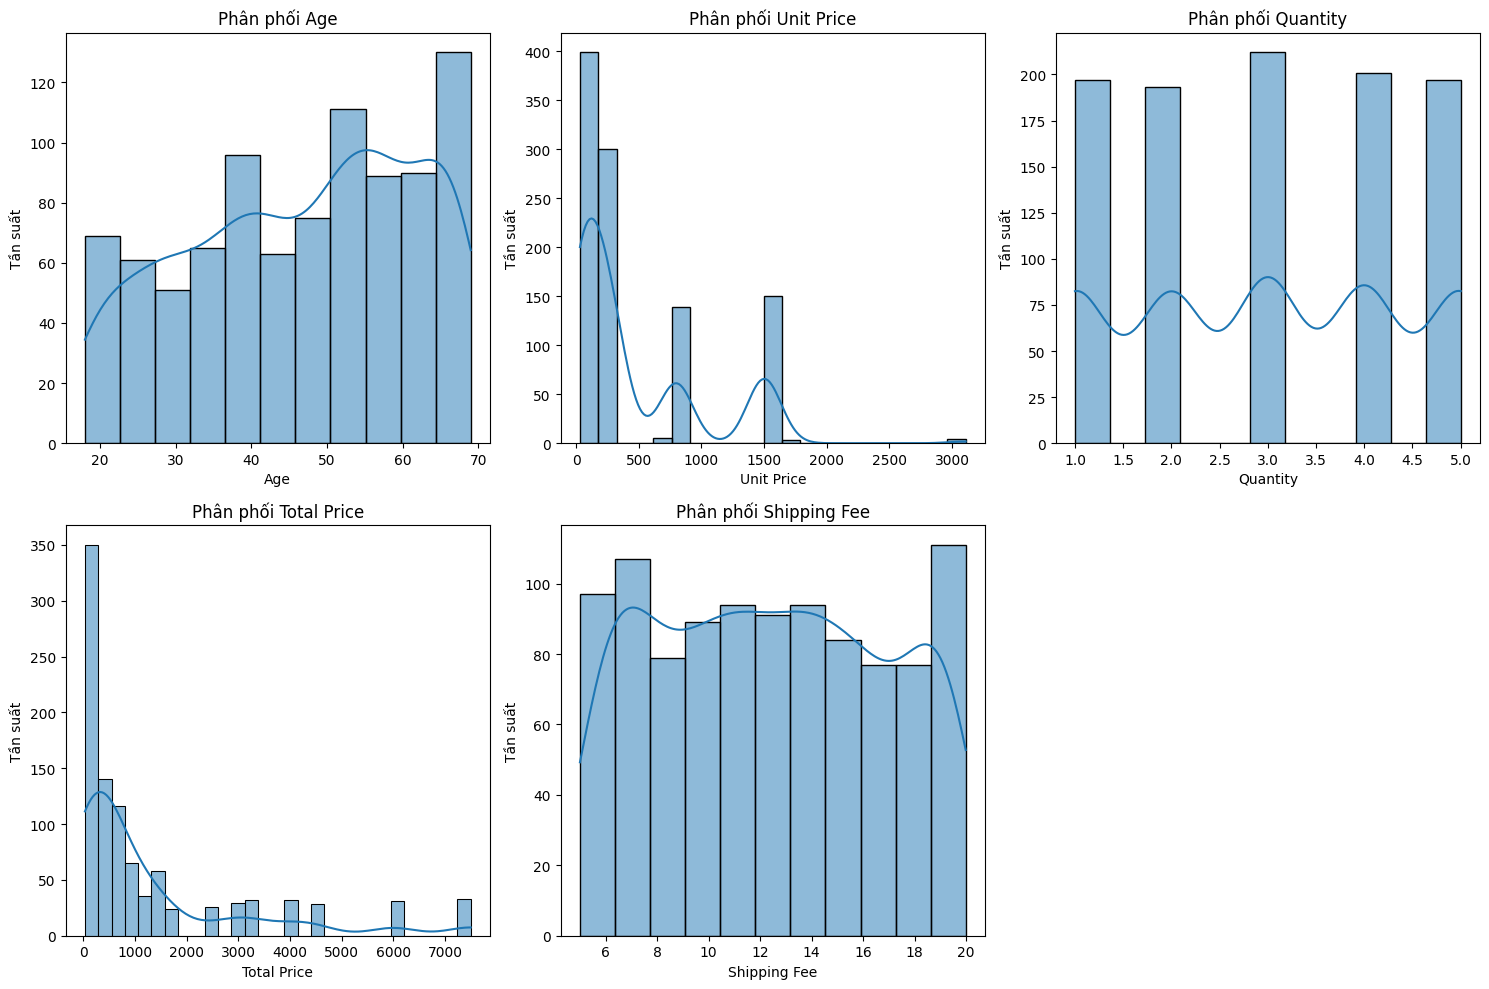

In [3]:
# Phân phối các biến số
numerical_cols = ['Age', 'Unit Price', 'Quantity', 'Total Price', 'Shipping Fee']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Phân phối {col}')
    plt.xlabel(col)
    plt.ylabel('Tần suất')

plt.tight_layout()
plt.show()

### 2.2. Phân phối các biến phân loại (Categorical Features Distribution)

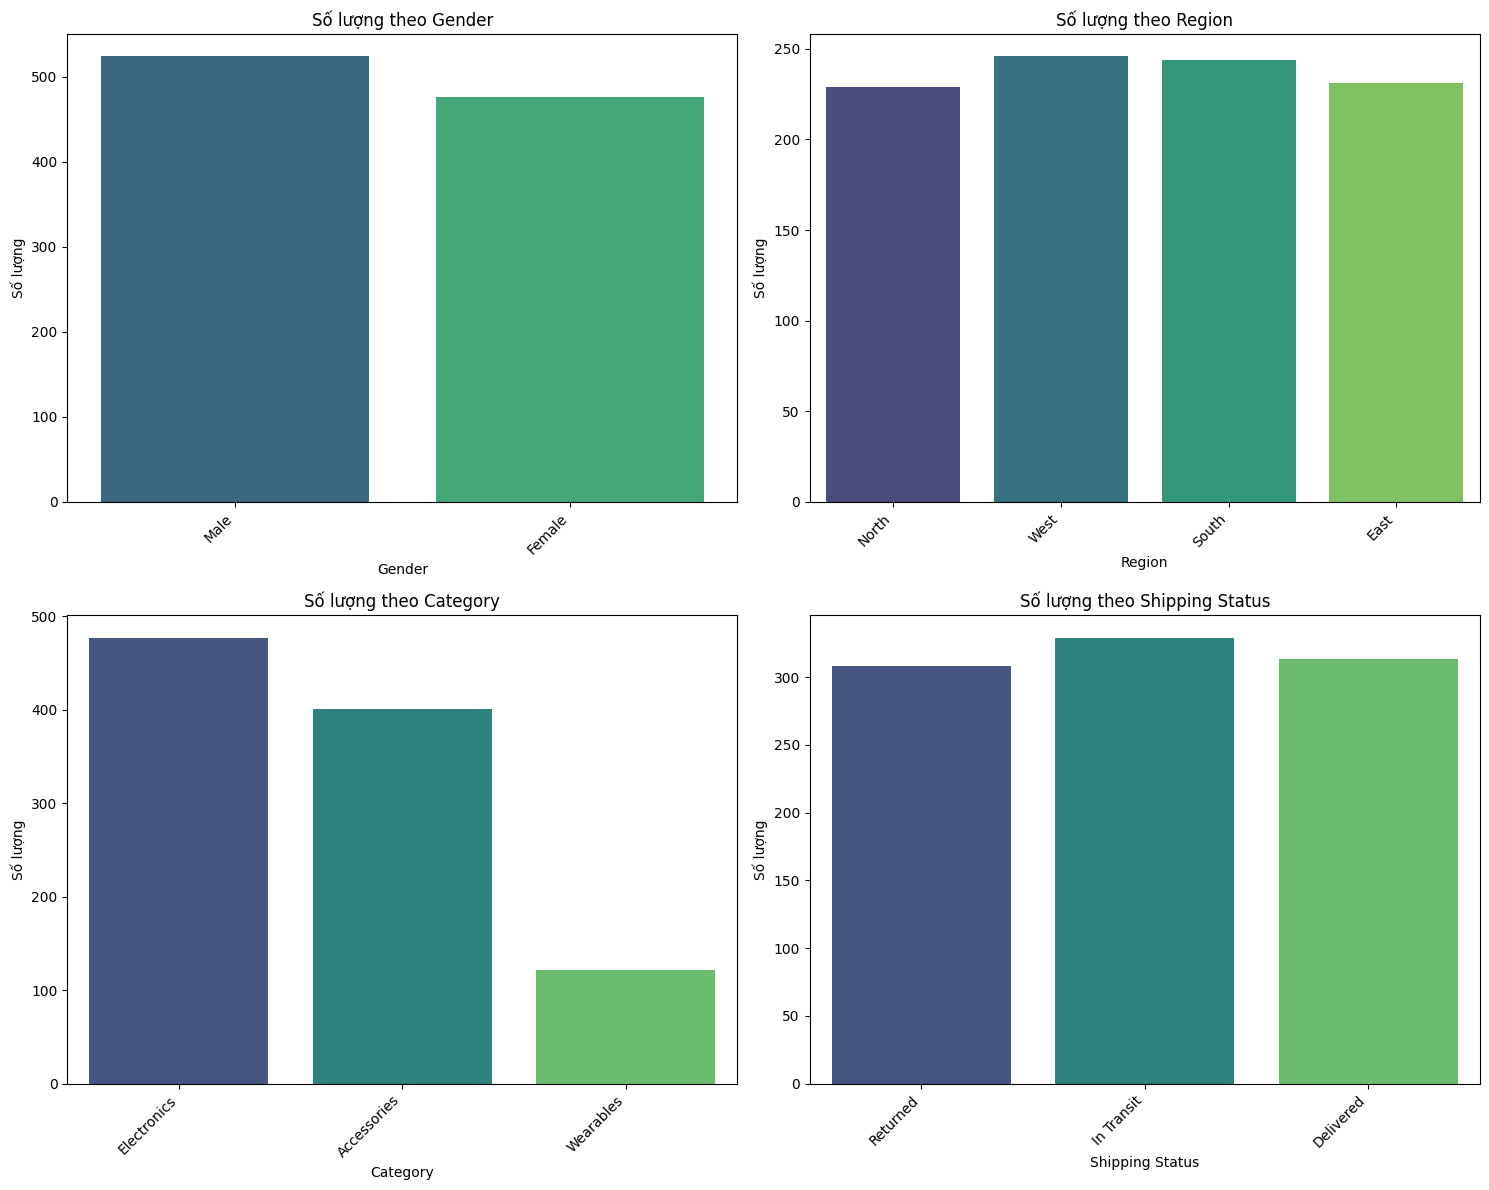

In [4]:
# Phân phối các biến phân loại
categorical_cols = ['Gender', 'Region', 'Category', 'Shipping Status']

plt.figure(figsize=(15, 12))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=col, palette='viridis', hue=col, legend=False)
    plt.title(f'Số lượng theo {col}')
    plt.xlabel(col)
    plt.ylabel('Số lượng')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 2.3. Doanh số theo thời gian (Sales Over Time)

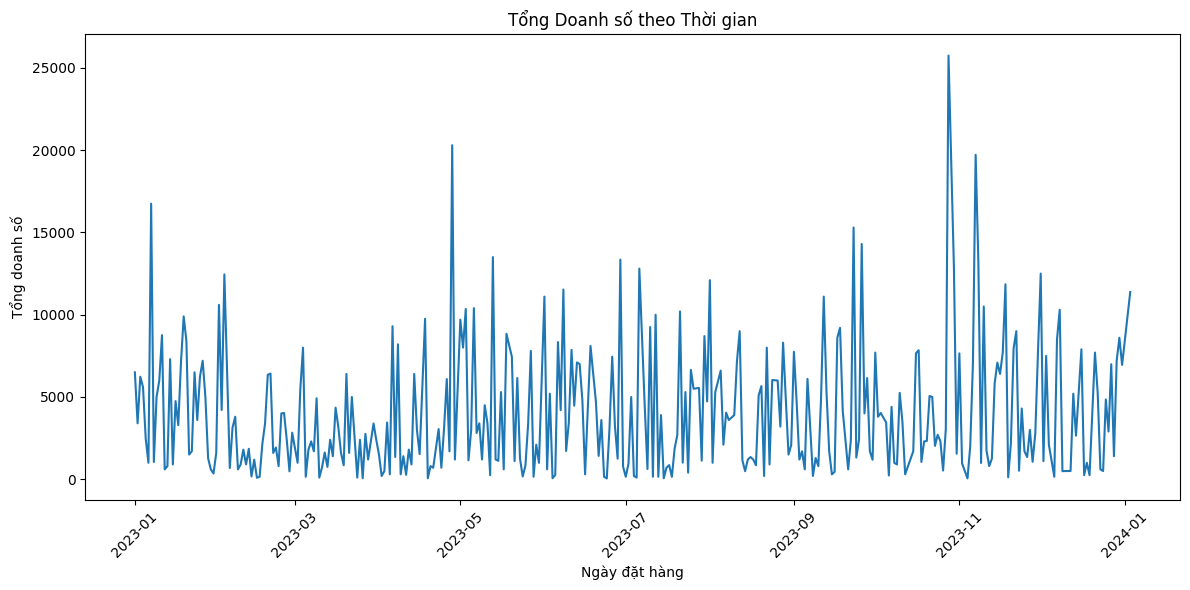

In [5]:
# Chuyển đổi 'Order Date' sang datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Tổng doanh số theo ngày
daily_sales = df.groupby('Order Date')['Total Price'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_sales, x='Order Date', y='Total Price')
plt.title('Tổng Doanh số theo Thời gian')
plt.xlabel('Ngày đặt hàng')
plt.ylabel('Tổng doanh số')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Tiền xử lý dữ liệu (Preprocessing)

In [6]:
# Kiểm tra giá trị bị thiếu
print("Số giá trị bị thiếu theo từng cột:")
print(df.isnull().sum())
print(f"\nKích thước DataFrame trước khi xóa null: {df.shape}")

# Xóa bỏ dữ liệu trống
df_cleaned = df.dropna()
print(f"Kích thước DataFrame sau khi xóa null: {df_cleaned.shape}")

# Tách đặc trưng (X) và biến mục tiêu (y)
# Loại bỏ các cột không phải đặc trưng: Customer ID, Product Name, Order Date, Total Price
X = df_cleaned.drop(columns=['Customer ID', 'Total Price', 'Product Name', 'Order Date'])
y = df_cleaned['Total Price']

# Chia tập Train/Test (Tỷ lệ 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nKích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test:  {X_test.shape}")
print(f"\nCác đặc trưng sử dụng: {list(X.columns)}")

Số giá trị bị thiếu theo từng cột:
Customer ID          0
Gender               0
Region              50
Age                100
Product Name         0
Category             0
Unit Price           0
Quantity             0
Total Price          0
Shipping Fee         0
Shipping Status     50
Order Date           0
dtype: int64

Kích thước DataFrame trước khi xóa null: (1000, 12)
Kích thước DataFrame sau khi xóa null: (810, 12)

Kích thước tập Train: (648, 8)
Kích thước tập Test:  (162, 8)

Các đặc trưng sử dụng: ['Gender', 'Region', 'Age', 'Category', 'Unit Price', 'Quantity', 'Shipping Fee', 'Shipping Status']


## 4. Xây dựng và Huấn luyện mô hình

Sử dụng Pipeline kết hợp:
- **StandardScaler** cho các đặc trưng số
- **OneHotEncoder** cho các đặc trưng phân loại

Huấn luyện 2 mô hình:
1. **Hồi quy Tuyến tính (Linear Regression)**
2. **Hồi quy Đa thức (Polynomial Regression)** bậc 2

In [7]:
# --- Định nghĩa các đặc trưng ---
numerical_features = ['Age', 'Unit Price', 'Quantity', 'Shipping Fee']
categorical_features = ['Gender', 'Region', 'Category', 'Shipping Status']

# --- Mô hình 1: Hồi quy Tuyến tính ---
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Huấn luyện
model_lr.fit(X_train, y_train)
print("Mô hình Hồi quy Tuyến tính đã được huấn luyện thành công!")

Mô hình Hồi quy Tuyến tính đã được huấn luyện thành công!


In [8]:
# --- Mô hình 2: Hồi quy Đa thức (bậc 2) ---
numerical_transformer_poly = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

categorical_transformer_poly = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_poly, numerical_features),
        ('cat', categorical_transformer_poly, categorical_features)
    ])

model_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('regressor', LinearRegression())
])

# Huấn luyện
model_poly.fit(X_train, y_train)
print("Mô hình Hồi quy Đa thức đã được huấn luyện thành công!")

Mô hình Hồi quy Đa thức đã được huấn luyện thành công!


## 5. Dự đoán và Đánh giá kết quả

BẢNG SO SÁNH CÁC MÔ HÌNH:


,Model,MSE,MAE,R2 Score
0,Linear Regression,964852.837011,662.004653,0.779279
1,Polynomial Regression (degree=2),114798.896119,146.881968,0.973738


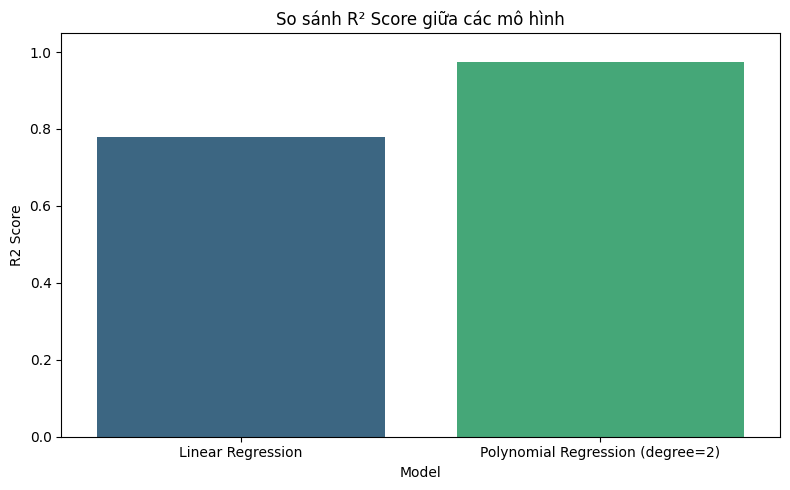

In [9]:
# Dự đoán trên tập Test
y_pred_lr = model_lr.predict(X_test)
y_pred_poly = model_poly.predict(X_test)

# Tổng hợp kết quả đánh giá
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial Regression (degree=2)'],
    'MSE': [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_poly)
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_poly)
    ],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_poly)
    ]
})

print("BẢNG SO SÁNH CÁC MÔ HÌNH:")
display(results)

# Biểu đồ so sánh R2 Score
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='R2 Score', data=results, palette='viridis')
plt.title('So sánh R² Score giữa các mô hình')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### 5.1. Biểu đồ đánh giá Mô hình Hồi quy Tuyến tính

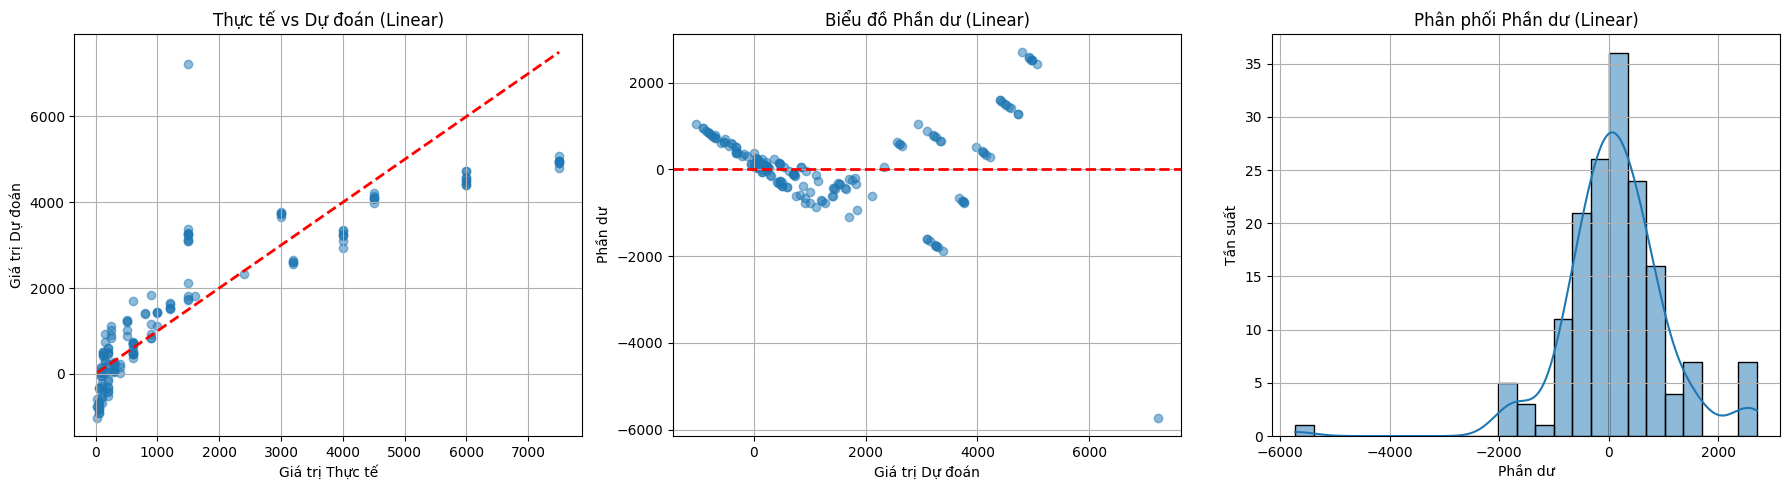

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Giá trị Dự đoán vs Thực tế
axes[0].scatter(y_test, y_pred_lr, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
axes[0].set_title('Thực tế vs Dự đoán (Linear)')
axes[0].set_xlabel('Giá trị Thực tế')
axes[0].set_ylabel('Giá trị Dự đoán')
axes[0].grid(True)

# 2. Biểu đồ Phần dư
residuals_lr = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuals_lr, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_title('Biểu đồ Phần dư (Linear)')
axes[1].set_xlabel('Giá trị Dự đoán')
axes[1].set_ylabel('Phần dư')
axes[1].grid(True)

# 3. Phân phối Phần dư
sns.histplot(residuals_lr, kde=True, ax=axes[2])
axes[2].set_title('Phân phối Phần dư (Linear)')
axes[2].set_xlabel('Phần dư')
axes[2].set_ylabel('Tần suất')
axes[2].grid(True)

plt.tight_layout()
plt.show()

### 5.2. Biểu đồ đánh giá Mô hình Hồi quy Đa thức

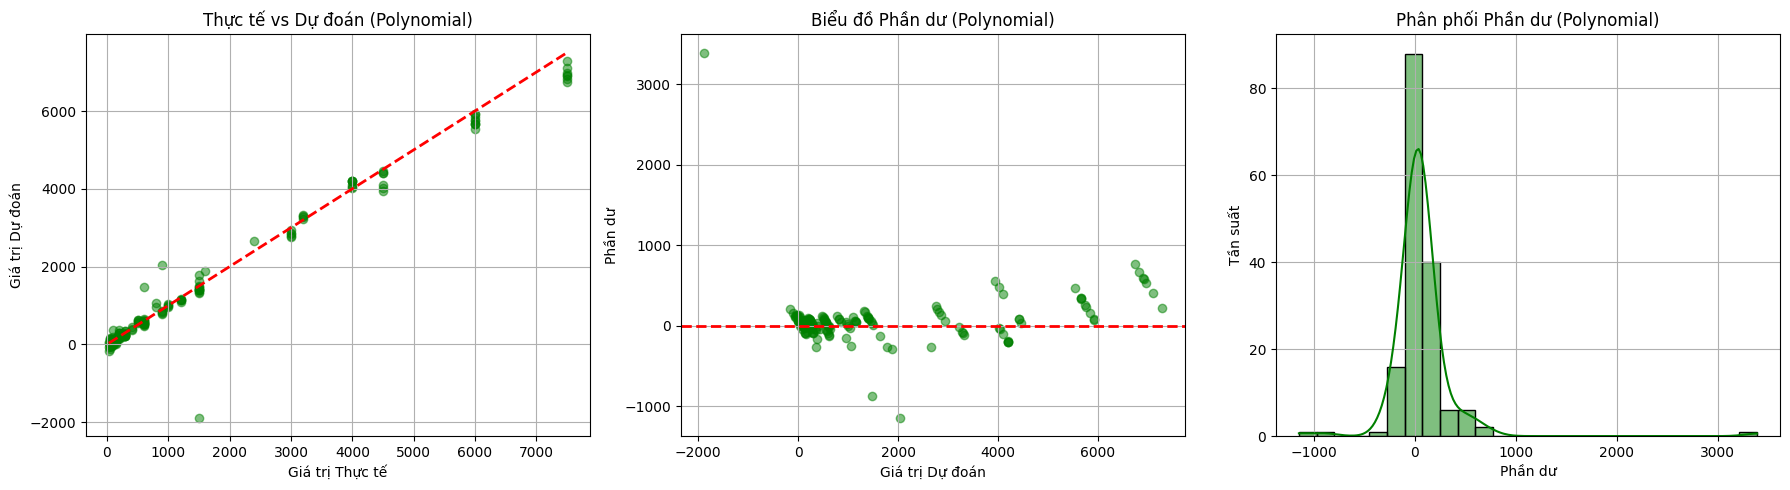

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Giá trị Dự đoán vs Thực tế
axes[0].scatter(y_test, y_pred_poly, alpha=0.5, color='green')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
axes[0].set_title('Thực tế vs Dự đoán (Polynomial)')
axes[0].set_xlabel('Giá trị Thực tế')
axes[0].set_ylabel('Giá trị Dự đoán')
axes[0].grid(True)

# 2. Biểu đồ Phần dư
residuals_poly = y_test - y_pred_poly
axes[1].scatter(y_pred_poly, residuals_poly, alpha=0.5, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_title('Biểu đồ Phần dư (Polynomial)')
axes[1].set_xlabel('Giá trị Dự đoán')
axes[1].set_ylabel('Phần dư')
axes[1].grid(True)

# 3. Phân phối Phần dư
sns.histplot(residuals_poly, kde=True, ax=axes[2], color='green')
axes[2].set_title('Phân phối Phần dư (Polynomial)')
axes[2].set_xlabel('Phần dư')
axes[2].set_ylabel('Tần suất')
axes[2].grid(True)

plt.tight_layout()
plt.show()